In [1]:
%reset -f
%matplotlib inline
%config InlineBackend.figure_format='retina'
import json
import math
import numpy as np
import matplotlib.pyplot as plt

def print_json(obj):
    print(json.dumps(obj, indent=2))

# GOSSIP REACH MODEL

Mean-field model of epidemic gossip propagation through the network, with and without deduplication cache. The key insights are the number of nodes informed and peak traffic bursts.

In [2]:
def gossip_coverage_with_dedup(N, d, L):
    """
    Returns the expectation of the total number of nodes reached by the last hop, where each node drops gossips
    already seen (i.e., not forwarded if seen earlier, called gossip deduplication).
    Also returns the network packet load in the last hop.
    
    Assuming perfect deduplication (every seen gossip is dropped); imperfection slightly increases reach and
    the forwaring load but the difference is insignificant.
    
    Assuming each node picks a random peer per transmit; implying assumption of reasonably uniform peer sampling.

    N: number of nodes in the network
    d: unicast gossip outdegree (number of destinations per hop)
    L: gossip message TTL (forward hop count)
    """
    S = 1  # informed nodes (nodes that received the gossip), incl. the origin
    A = 1  # expansion per hop (nodes that became informed in that hop), initially just the origin node
    for hop in range(L):
        M = d * A  # number of transmissions across all nodes at this hop
        # Model spread A_h+1 as balls into bins / coupon's collector problem:
        # - https://en.wikipedia.org/wiki/Balls_into_bins_problem
        # - https://en.wikipedia.org/wiki/Coupon_collector%27s_problem
        A_next = (N - S) * (1 - np.exp(-M / (N-1)))
        S_next = S + A_next
        S, A = S_next, A_next
        #print(f"hop {hop}: reached {S: 4.0f}/{N} nodes so far, contacted {A: 3.0f} new nodes this hop")
    return int(S), int(d * A)


def gossip_coverage_no_dedup(N, d, L):
    """
    The counterpart for the coverage-with-dedup model that assumes that nodes do not deduplicate seen gossips.
    Simple algebraic closed forms exist, but we use this iterative model for parity with the dedup model.
    """
    S = 1        # unique informed nodes, includes origin
    copies = 1   # copies at current frontier (origin copy initially)
    M_last = 0
    for hop in range(L):
        M = d * copies                   # all copies forward
        M_last = M
        A_next = (N - S) * (1.0 - np.exp(-M / (N - 1)))  # see the other model
        S += A_next
        copies = M                       # next hop has one copy per tx
    return int(S), int(M_last)


gossip_coverage_with_dedup(300, 2, 10)
#gossip_coverage_no_dedup(300, 2, 10)

(226, 32)

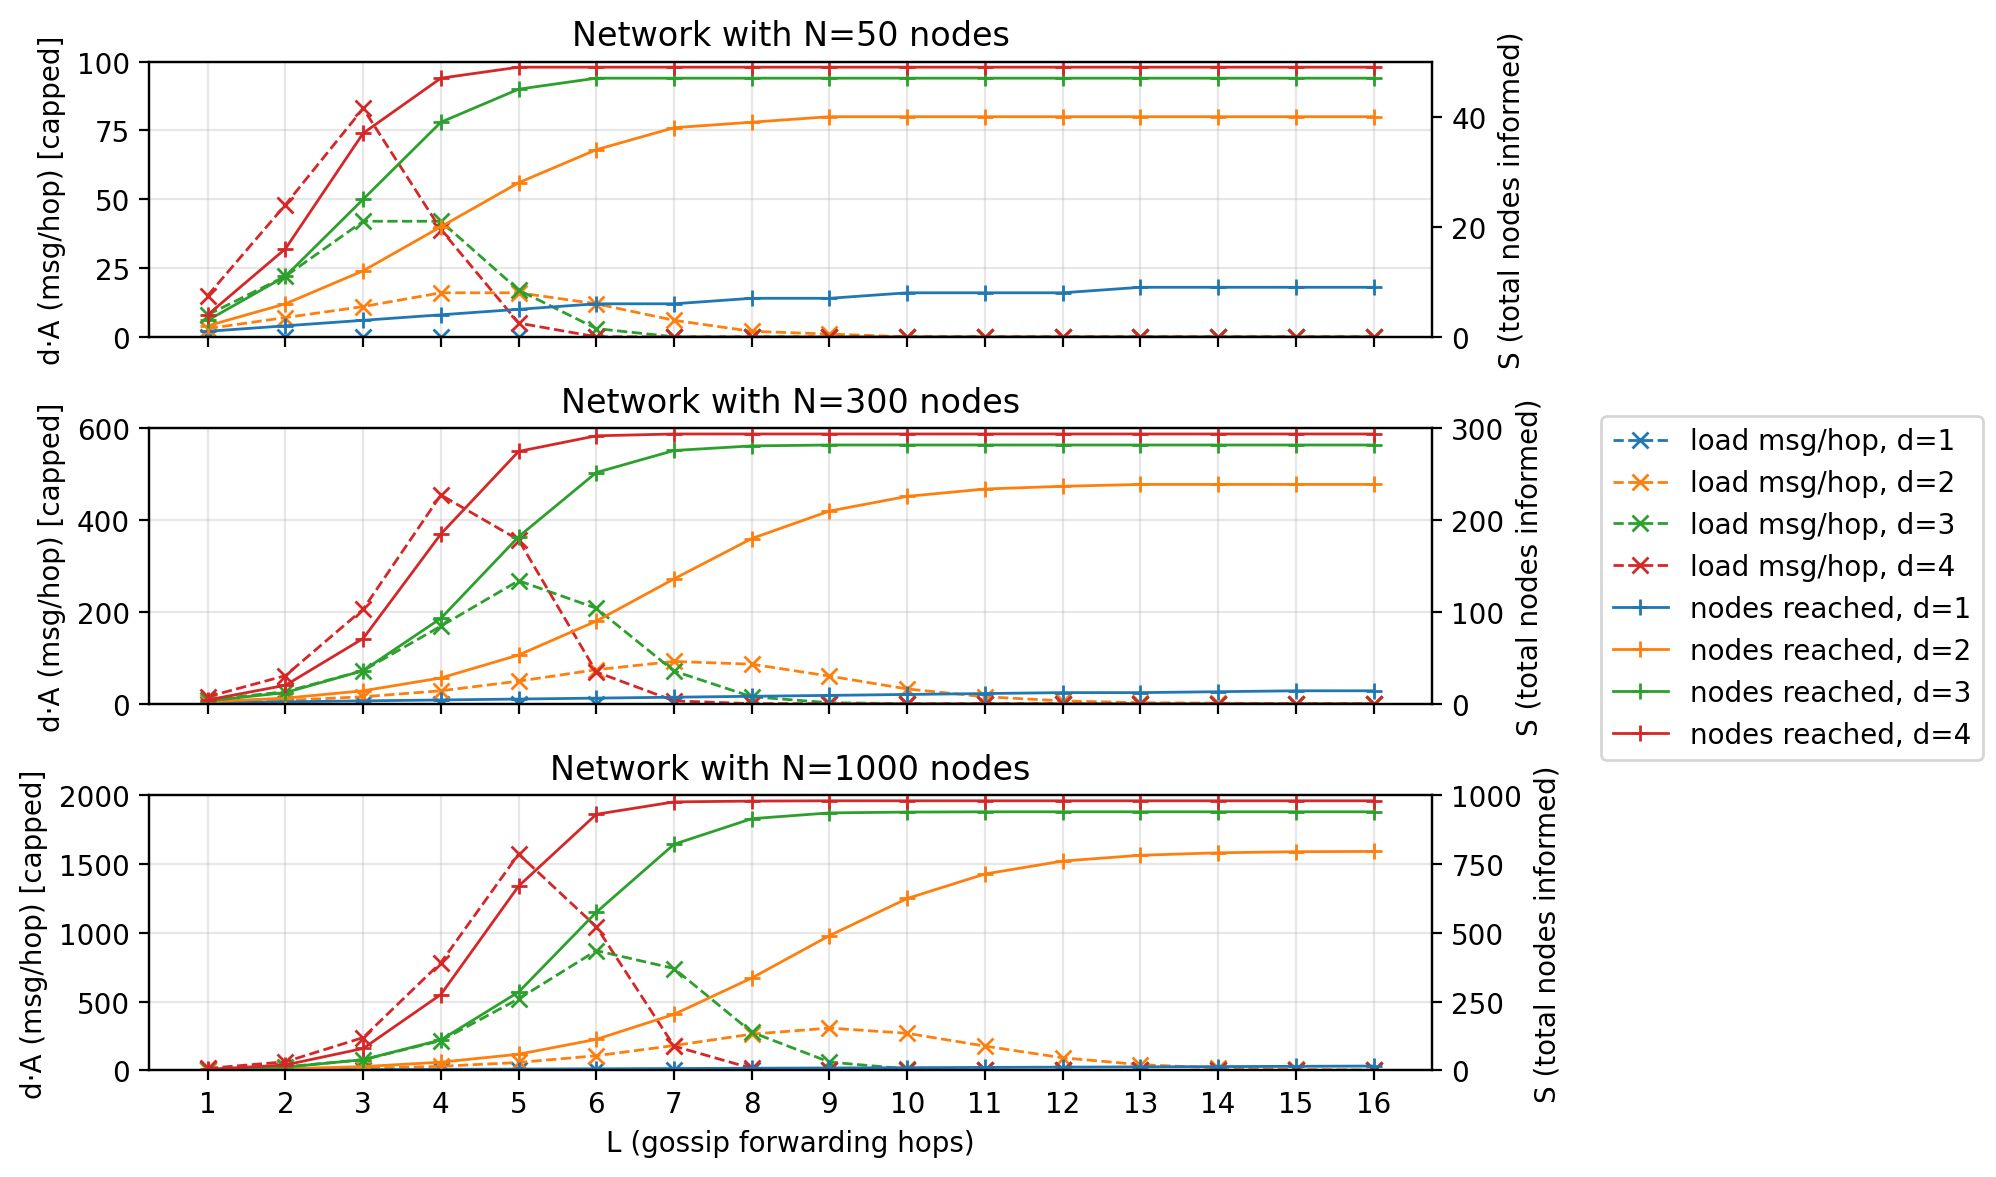

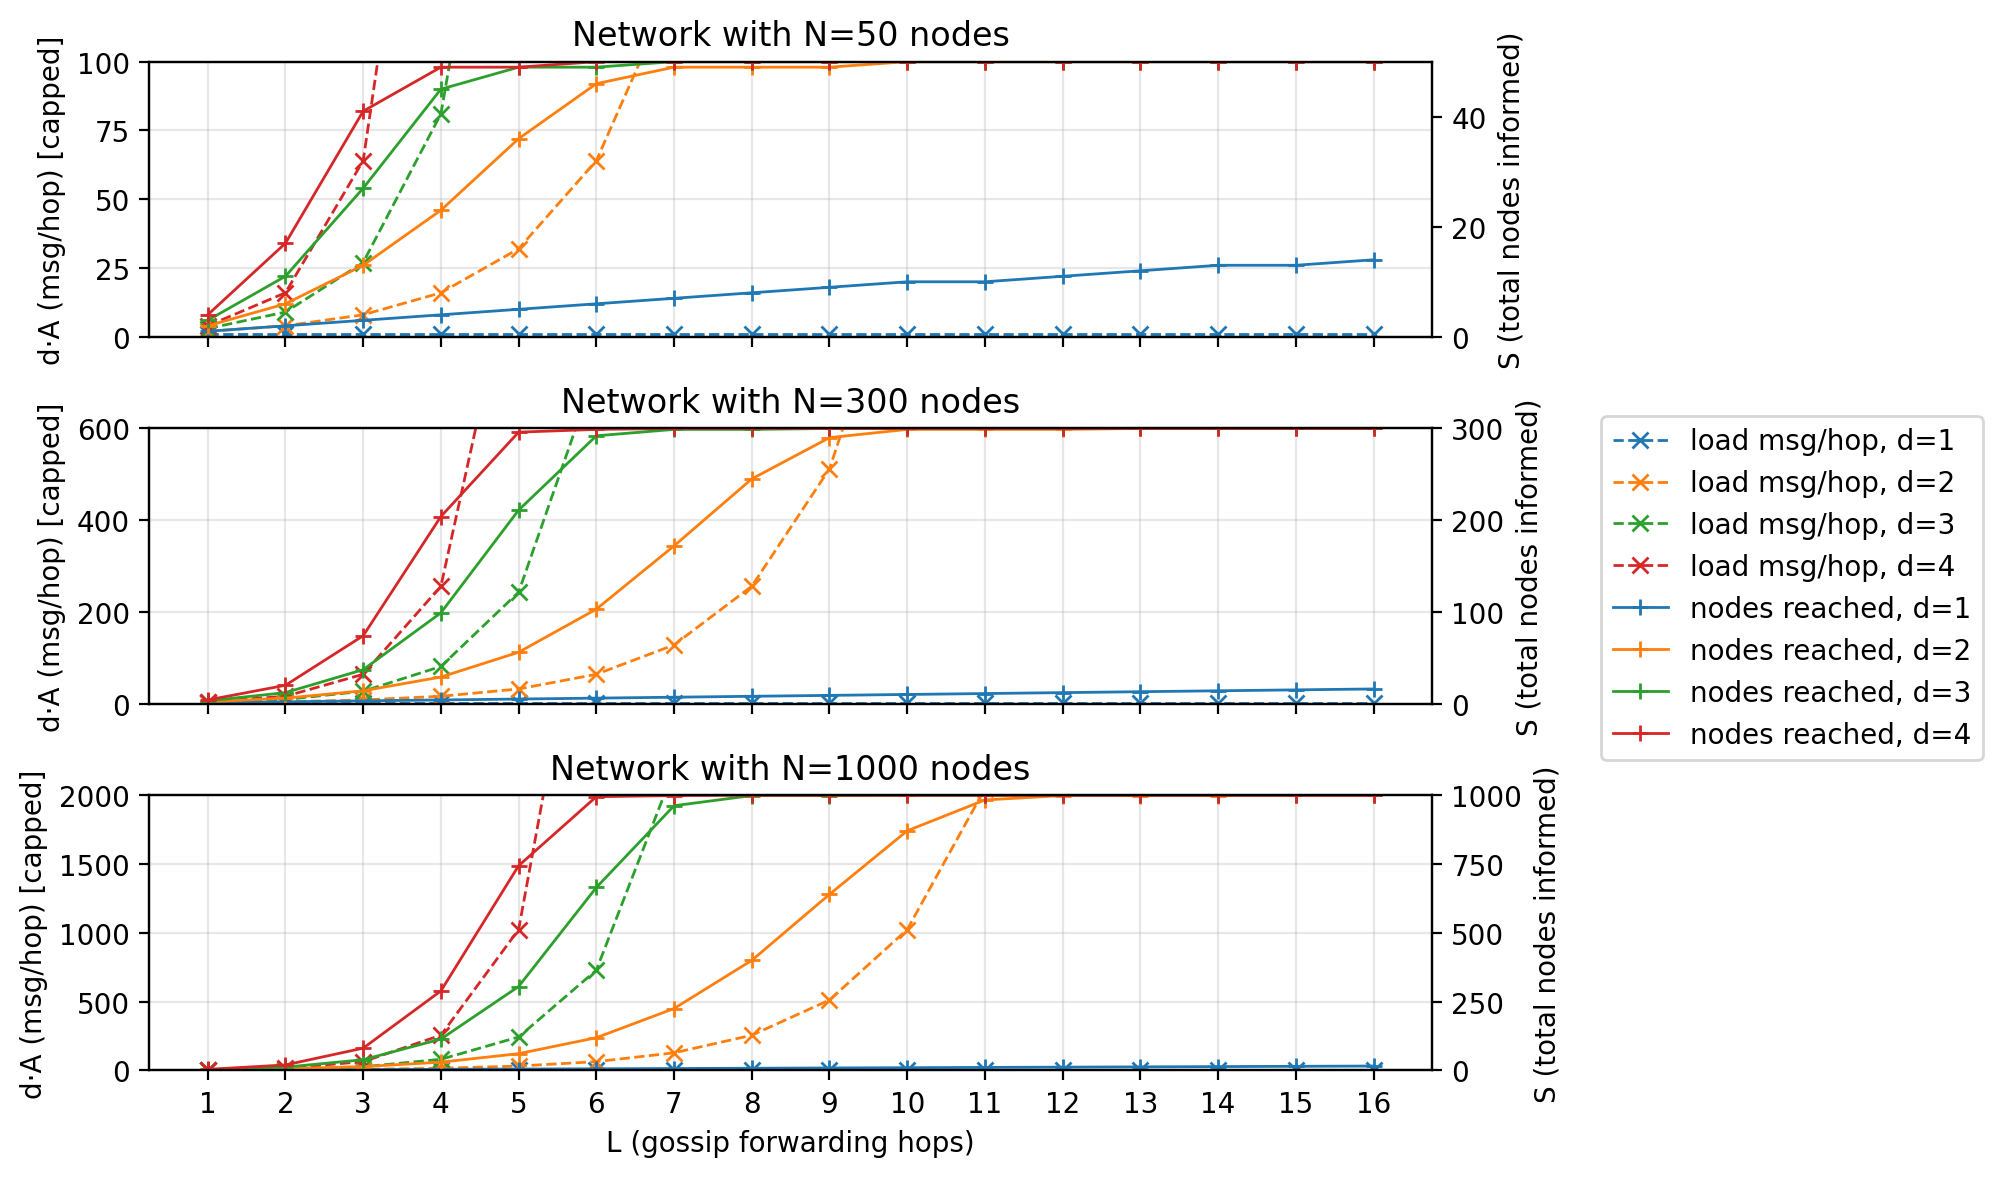

In [3]:
def plot_gossip_coverage(Ns, ds, model, L_max=16):
    Ls = list(range(1, L_max+1))
    fig, axes = plt.subplots(len(Ns), 1, figsize=(10, 6), sharex=True)
    cov_axes = []
    for ax_load, N in zip(axes, Ns):
        ax_cov = ax_load.twinx()
        cov_axes.append(ax_cov)
        for d in ds:
            results = [model(N, d, L) for L in Ls]
            coverage = [r[0] for r in results]
            load = [r[1] for r in results]
            ax_load.plot(
                Ls,
                load,
                linestyle="--",
                marker="x",
                linewidth=1,
                label=f"load msg/hop, d={d}",
            )
            ax_cov.plot(
                Ls,
                coverage,
                marker="+",
                linewidth=1,
                label=f"nodes reached, d={d}",
            )
    
        ax_load.set_title(f"Network with N={N} nodes")
        ax_load.set_ylabel("d·A (msg/hop) [capped]")
        ax_cov.set_ylabel("S (total nodes informed)")
        ax_load.set_ylim(0, N*2)
        ax_cov.set_ylim(0, N)
        ax_load.set_xticks(Ls)
        ax_load.grid(True, alpha=0.3)
    axes[-1].set_xlabel("L (gossip forwarding hops)")
    handles_load, labels_load = axes[0].get_legend_handles_labels()
    handles_cov, labels_cov = cov_axes[0].get_legend_handles_labels()
    fig.legend(
        handles_load + handles_cov,
        labels_load + labels_cov,
        loc="center right",
    )
    fig.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

for model in (gossip_coverage_with_dedup, gossip_coverage_no_dedup):
    plot_gossip_coverage(Ns=[50, 300, 1000], ds=[1, 2, 3, 4], model=model)

# GOSSIP ARRIVAL LOAD

Mean-field model of the incoming traffic generated by gossip messages per node. This is used to derive protocol parameters given specific processing load caps per node.

In [4]:
def gossip_arrival_rate_with_dedup(N, d, L, r):
    """
    Model of the gossip message arrival load PER NODE as a function of epidemic parameters.
    This model informs the choice of periodic gossip parameters.
    
    N: node count
    d: outdegree
    L: number of forwarding hops (same semantics as range(L))
    r: new gossip origination rate per node [gossips/s/node, Hz/node]

    Returns:
        rx_per_node_hz: total unicast arrivals per node [msg/s]
        reached_expected: expected unique reached nodes after L hops
        tx_per_origin: expected total unicast tx for one originated gossip
    """
    S = 1  # informed unique nodes
    A = 1  # newly informed on current hop frontier (origin initially)
    hop_M = []
    for hop in range(L):
        M = d * A
        hop_M.append(M)
        if N > 1:
            A_next = (N - S) * (1.0 - math.exp(-M / (N - 1)))
        else:
            A_next = 0.0
        S += A_next
        A = A_next
    tx_per_origin = sum(hop_M)
    hop_rx_per_node_hz = [r * m for m in hop_M]
    rx_per_node_hz = sum(hop_rx_per_node_hz)
    return rx_per_node_hz, int(S), tx_per_origin

gossip_arrival_rate_with_dedup(300, 2, 16, 1)

(479.5548590762277, 239, 479.5548590762277)

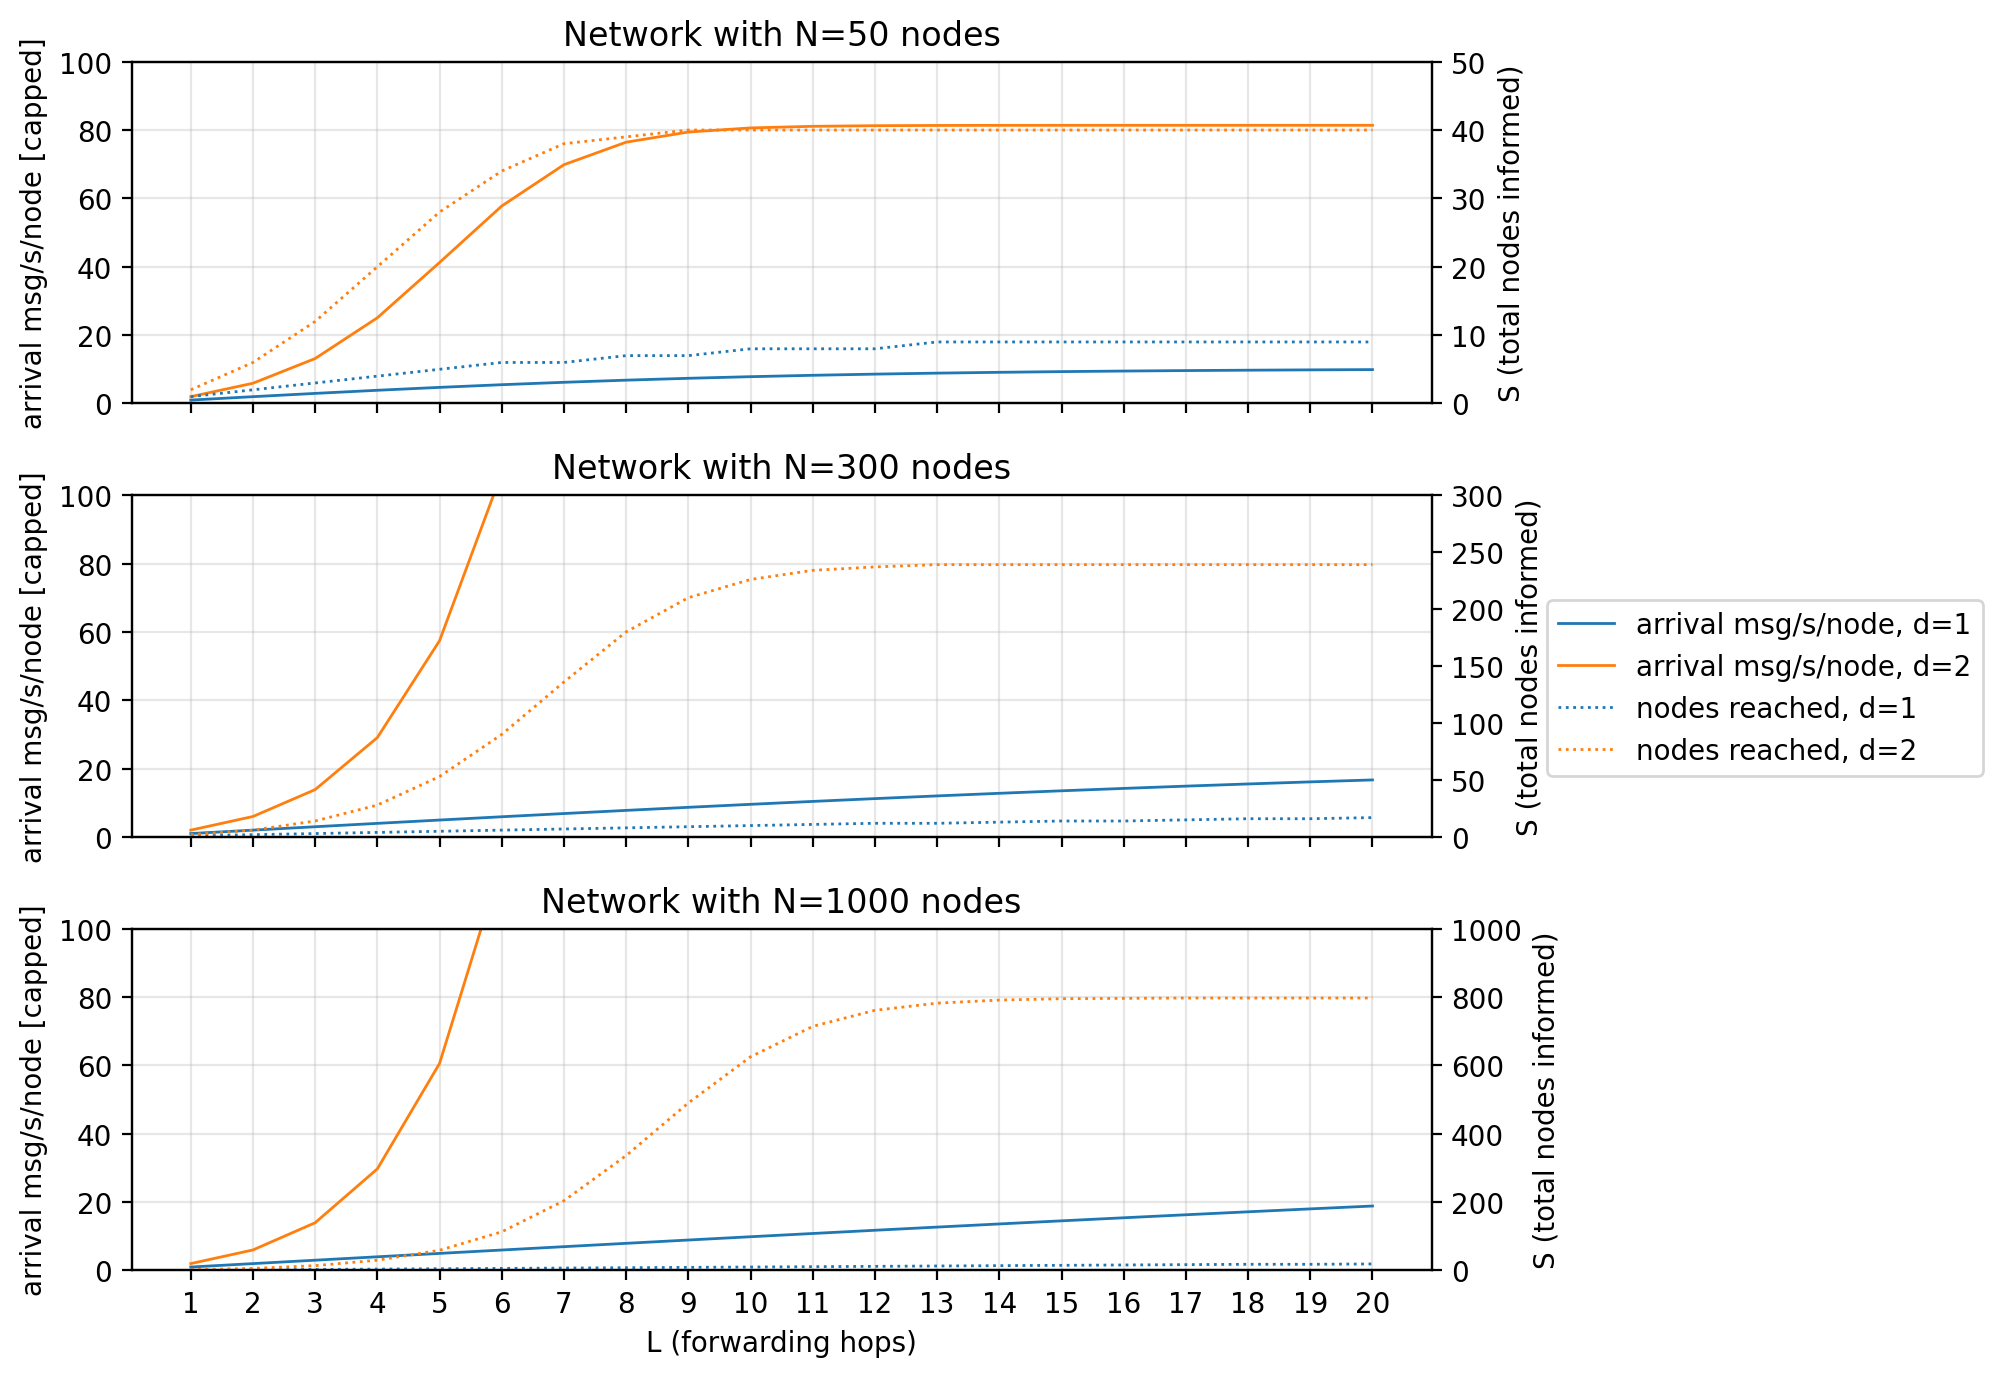

In [5]:
def plot_gossip_arrival_rate(Ns, ds, model, rate=1, L_max=20):
    Ls = list(range(1, L_max+1))
    fig, axes = plt.subplots(len(Ns), 1, figsize=(10, 7), sharex=True)
    cov_axes = []
    for ax_load, N in zip(axes, Ns):
        ax_cov = ax_load.twinx()
        cov_axes.append(ax_cov)
        for d in ds:
            results = [model(N=N, d=d, L=L, r=rate) for L in Ls]
            coverage = [r[1] for r in results]
            load = [r[0] for r in results]
            ax_load.plot(
                Ls,
                load,
                linewidth=1,
                label=f"arrival msg/s/node, d={d}",
            )
            ax_cov.plot(
                Ls,
                coverage,
                linestyle=":",
                linewidth=1,
                label=f"nodes reached, d={d}",
            )
        ax_load.set_title(f"Network with N={N} nodes")
        ax_load.set_ylabel("arrival msg/s/node [capped]")
        ax_cov.set_ylabel("S (total nodes informed)")
        ax_load.set_ylim(0, 100)
        ax_cov.set_ylim(0, N)
        ax_load.set_xticks(Ls)
        ax_load.grid(True, alpha=0.3)
    axes[-1].set_xlabel("L (forwarding hops)")
    handles_load, labels_load = axes[0].get_legend_handles_labels()
    handles_cov, labels_cov = cov_axes[0].get_legend_handles_labels()
    fig.legend(
        handles_load + handles_cov,
        labels_load + labels_cov,
        loc="center right",
    )
    fig.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

plot_gossip_arrival_rate(Ns=[50, 300, 1000], ds=[1, 2], model=gossip_arrival_rate_with_dedup)

# ATTRACTOR GOSSIP MODEL

An extension of classic epidemic gossips that includes the optional attractor node ID in the message. The attractor is the remote node whose original gossip was found to be outdated (violates the consensus). The first gossip is sent like an ordinary epidemic gossip. Forwarding is done depending on whether the forwarder has the attractor in its peer set, in both cases only if the gossip passes the dedup filter (otherwise drop as usual):

- If the forwarder doesn't have the attractor in the peer set, forwarding is done as usual for epidemics ($d$ random unique peers excluding the sender).
- Otherwise, the gossip is sent directly to the attractor once. Optionally, if the original outdegree $d>1$, it can be reduced by one and forwarded to a random peer to continue propagation, but as the model shows it has limited utility.


In [6]:
def attractor_gossip(*, N, m=1, d=2, L=10, k=10):
    """
    Mean-field model of attractor gossip.

    N: total nodes in the network, including origin and attractor
    m: the number of near-simultaneous tx of same gossip (when multiple nodes detect divergence), usually 1
    d: outdegree, random fanout when attractor is not in peer set
    L: forwarding TTL in hops (same semantics as range(L))
    k: peer-set size

    Returns:
        reached_nodes: expected informed non-attractor nodes by final hop
        attractor_hit_prob: probability that at least one informed node had attractor in peer set
        attractor_arrivals: expected total tx to attractor
        tx_per_hop_random: per-hop epidemic tx (ordinary)
        tx_per_hop_attractor: per-hop tx direct to attractor
        tx_total: total messages exchanged across all hops
        q: probability a node has attractor in peer set
    """
    # Probability that a node has the attractor in its peer set is exact for uniform size-k random peer sets.
    # Given N nodes, the probability that nobody has the attractor is (1-q)^(N-1) ≈ e^-k, so the probability
    # of attractor hit is conveniently approximated as 1-e^-k.
    q = k / (N - 1)       
    N_pool = N - 1        # all non-attractor nodes, origin included
    if not (0 < m <= N_pool):
        raise ValueError
    # The effective branching factor (outdegree) considering propagation stop when the gossip hits
    # a node that has the attractor in its peer set. Key trade-off:
    # - larger peer set k raises q, attractor found sooner
    # - larger k lowers branching R_eff, fewer bystander nodes see the gossip
    # - larger k increases attractor arrival load as q·A per hop
    R_eff = d * (1 - q)
    # At a first glance it may seem counter-intuitive, but the number of originators m does not affect the
    # propagation dynamics that much thanks to the gossip dedup cache, assuming that all original gossips
    # are sent within a time window that is nontrivially smaller than the gossip dedup cache lifetime.
    # The first hop grows like d·m, subsequent hops multiply R_eff per hop. The key observations are:
    # - for small m, burden at the attractor grows linearly with m; but
    # - for large m, thanks to the distributed dedup cache the load grows sublinearly in m!
    S = float(m)         # informed non-attractor nodes
    A = float(m)         # frontier size (origin initially)
    hop_random = []      # per-hop epidemic tx (ordinary)
    hop_attractor = []   # per-hop tx to attractor
    informed_after_first_hop = 0.0
    for hop in range(L):
        if hop == 0: # Origin sends randomly as usual (even if attractor is a peer).
            U = 0.0
            M = d * A
        else:        # Forwarders either redirect to attractor or diffuse randomly.
            U = q * A
            M = R_eff * A
        hop_random.append(M)
        hop_attractor.append(U)
        if hop > 0:
            informed_after_first_hop += A
        A_next = 0.0
        if N_pool > 1:  # balls-into-bins model
            A_next = (N_pool - S) * (1.0 - math.exp(-M / (N_pool - 1)))
        S += A_next
        A = A_next

    attractor_hit_prob = 1.0 - (1.0 - q) ** informed_after_first_hop
    return dict(
        reached_nodes=S,
        attractor_hit_prob=attractor_hit_prob,
        tx_per_hop_random=hop_random,
        tx_per_hop_attractor=hop_attractor,
        tx_total=sum(hop_random) + sum(hop_attractor),
        attractor_arrivals=sum(hop_attractor),
        q=q,
    )

print_json(attractor_gossip(N=300))
print_json(attractor_gossip(N=300, m=250))

{
  "reached_nodes": 216.01571778831575,
  "attractor_hit_prob": 0.9987301109358825,
  "tx_per_hop_random": [
    2.0,
    3.853275816439912,
    7.351352224752081,
    13.764097552755523,
    24.87536118982994,
    42.14272835330898,
    63.837633718433196,
    81.03510265209275,
    80.76265929883701,
    61.353584933973224
  ],
  "tx_per_hop_attractor": [
    0.0,
    0.06666567156470436,
    0.12718602464968998,
    0.2381331756532097,
    0.4303695707583034,
    0.7291129472890827,
    1.1044573307687402,
    1.4019913953649263,
    1.3972778425404326,
    1.0614807082002287
  ],
  "tx_total": 387.5324704072119,
  "attractor_arrivals": 6.556674666789318,
  "q": 0.033444816053511704
}
{
  "reached_nodes": 292.0321435444532,
  "attractor_hit_prob": 0.7606438346968428,
  "tx_per_hop_random": [
    500.0,
    77.03066129666294,
    4.029912912459607,
    0.18350807496750518,
    0.008297383269360607,
    0.00037504842946097796,
    1.6952245438917582e-05,
    7.662435397283407e-07,
  

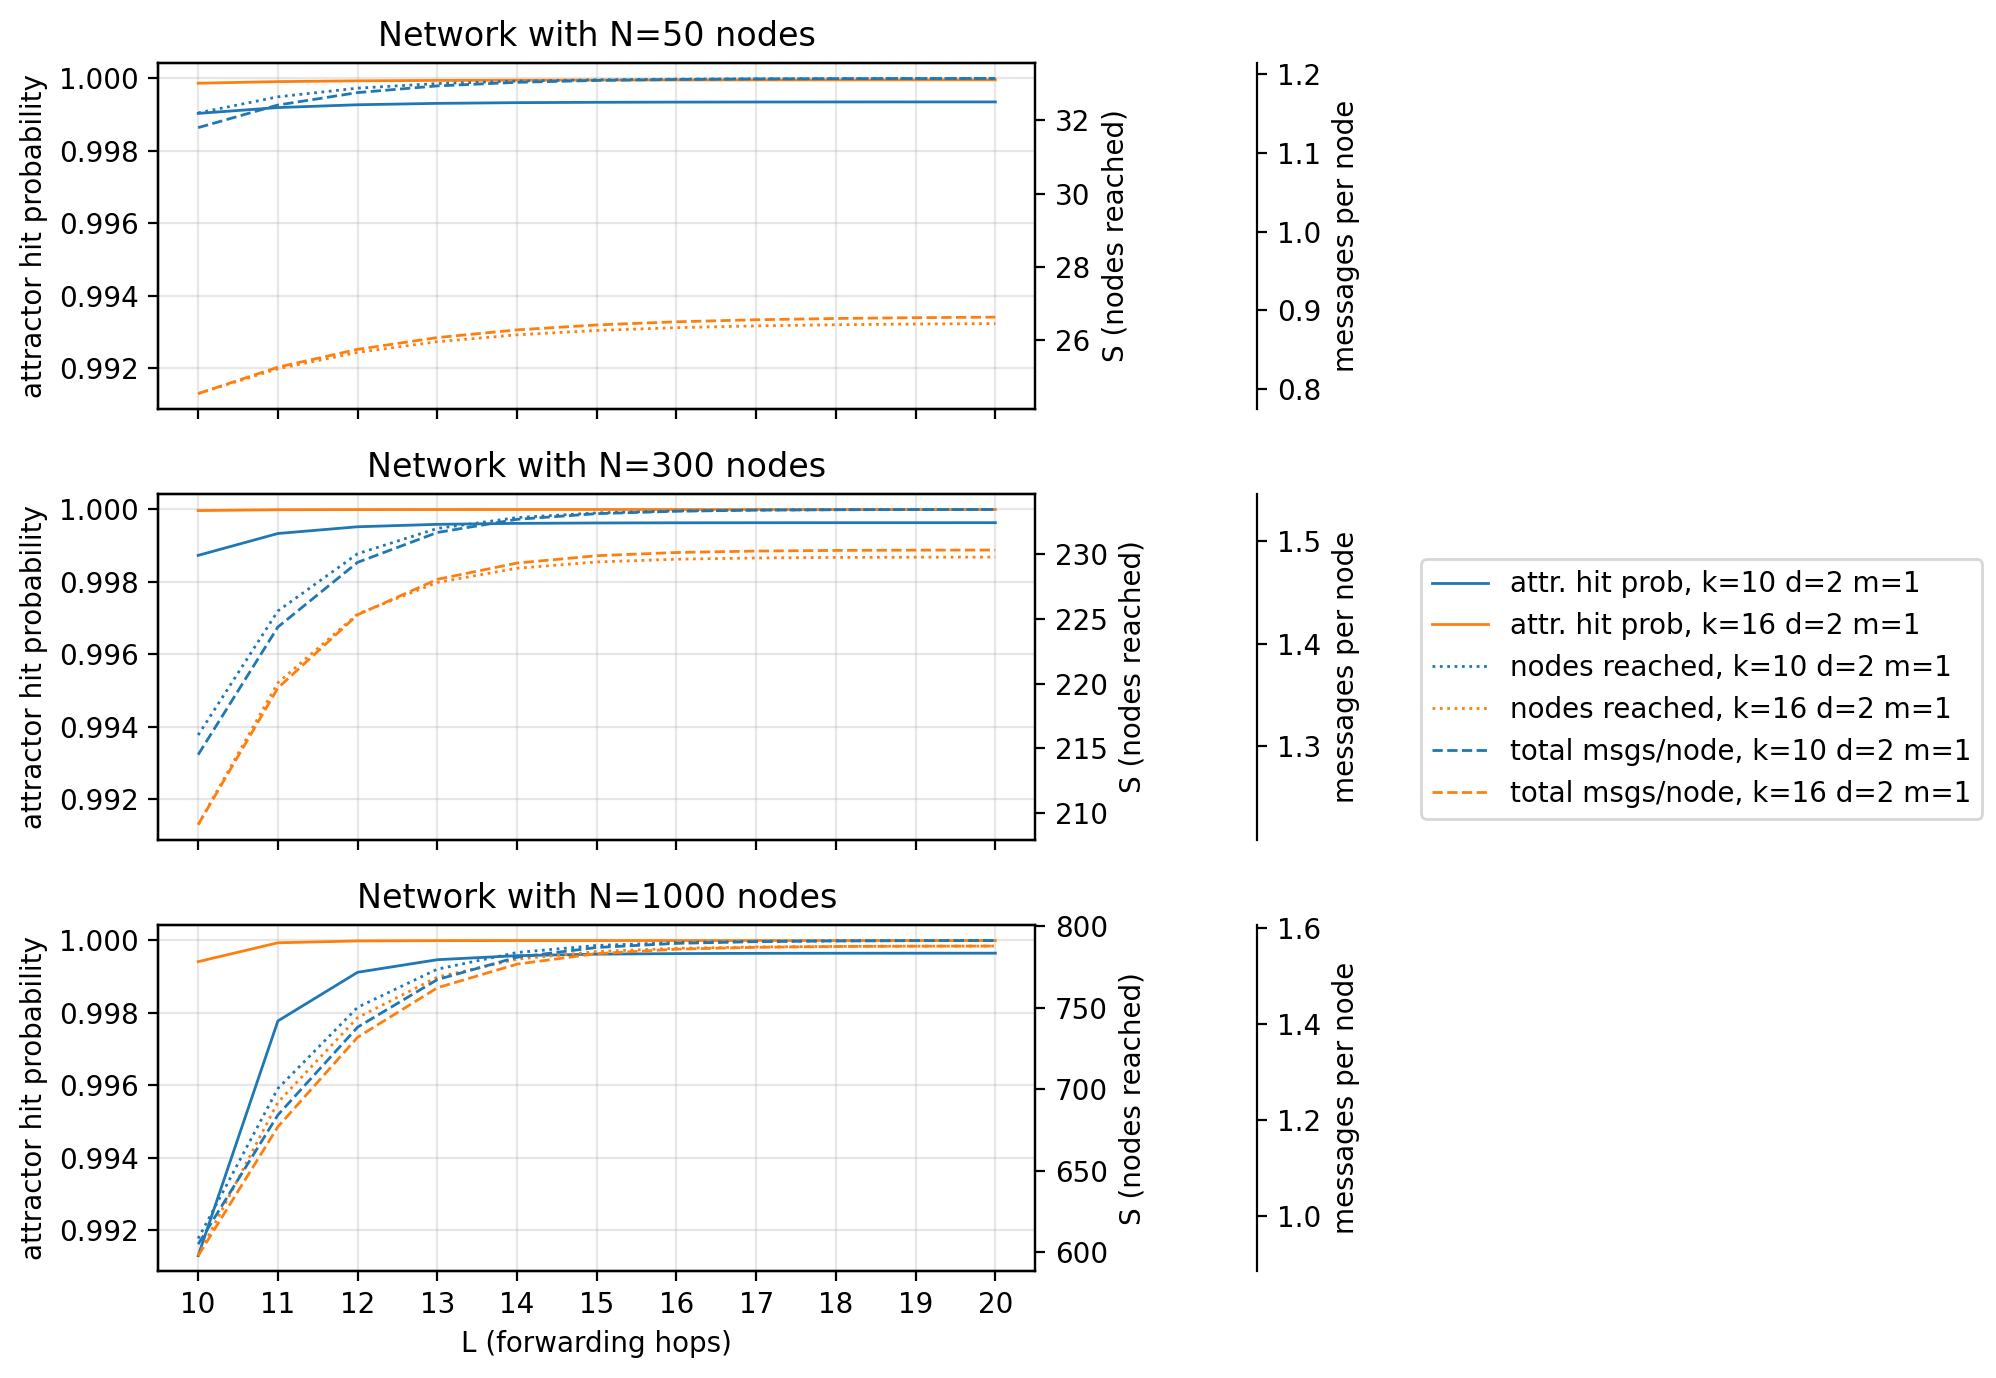

In [7]:
def plot_attractor_in_hops(Ns, ks, Ls, d=2, m=1):
    fig, axes0 = plt.subplots(len(Ns), 1, figsize=(10, 7), sharex=True, sharey=True)
    axes1 = []
    axes2 = []
    for ax0, N in zip(axes0, Ns):
        ax1 = ax0.twinx()
        ax2 = ax0.twinx()
        ax2.spines["right"].set_position(("outward", 80))
        axes1.append(ax1)
        axes2.append(ax2)
        for k in ks:
            results = [attractor_gossip(N=N, k=k, d=d, m=m, L=L) for L in Ls]
            options = f"k={k} d={d} m={m}"
            ax0.plot(
                Ls,
                [r["attractor_hit_prob"] for r in results],
                linewidth=1,
                label=f"attr. hit prob, {options}",
            )
            ax1.plot(
                Ls,
                [r["reached_nodes"] for r in results],
                linestyle=":",
                linewidth=1,
                label=f"nodes reached, {options}",
            )
            ax2.plot(
                Ls,
                [(r["tx_total"] / N) for r in results],
                linestyle="--",
                linewidth=1,
                label=f"total msgs/node, {options}",
            )
        ax0.set_title(f"Network with N={N} nodes")
        ax0.set_ylabel("attractor hit probability")
        ax0.set_xticks(Ls)
        ax0.grid(True, alpha=0.3)
        ax1.set_ylabel("S (nodes reached)")
        ax2.set_ylabel("messages per node")
    axes0[-1].set_xlabel("L (forwarding hops)")
    handles, labels = None, None
    for ax in (axes0, axes1, axes2):
        h, l = ax[0].get_legend_handles_labels()
        handles = h if handles is None else (handles + h)
        labels  = l if labels is None else (labels + l)
    fig.legend(handles, labels, loc="center right")
    fig.tight_layout(rect=[0, 0, 0.7, 1])
    plt.show()

plot_attractor_in_hops(Ns=[50, 300, 1000], ks=[10, 16], Ls=list(range(10, 21)), m=1)

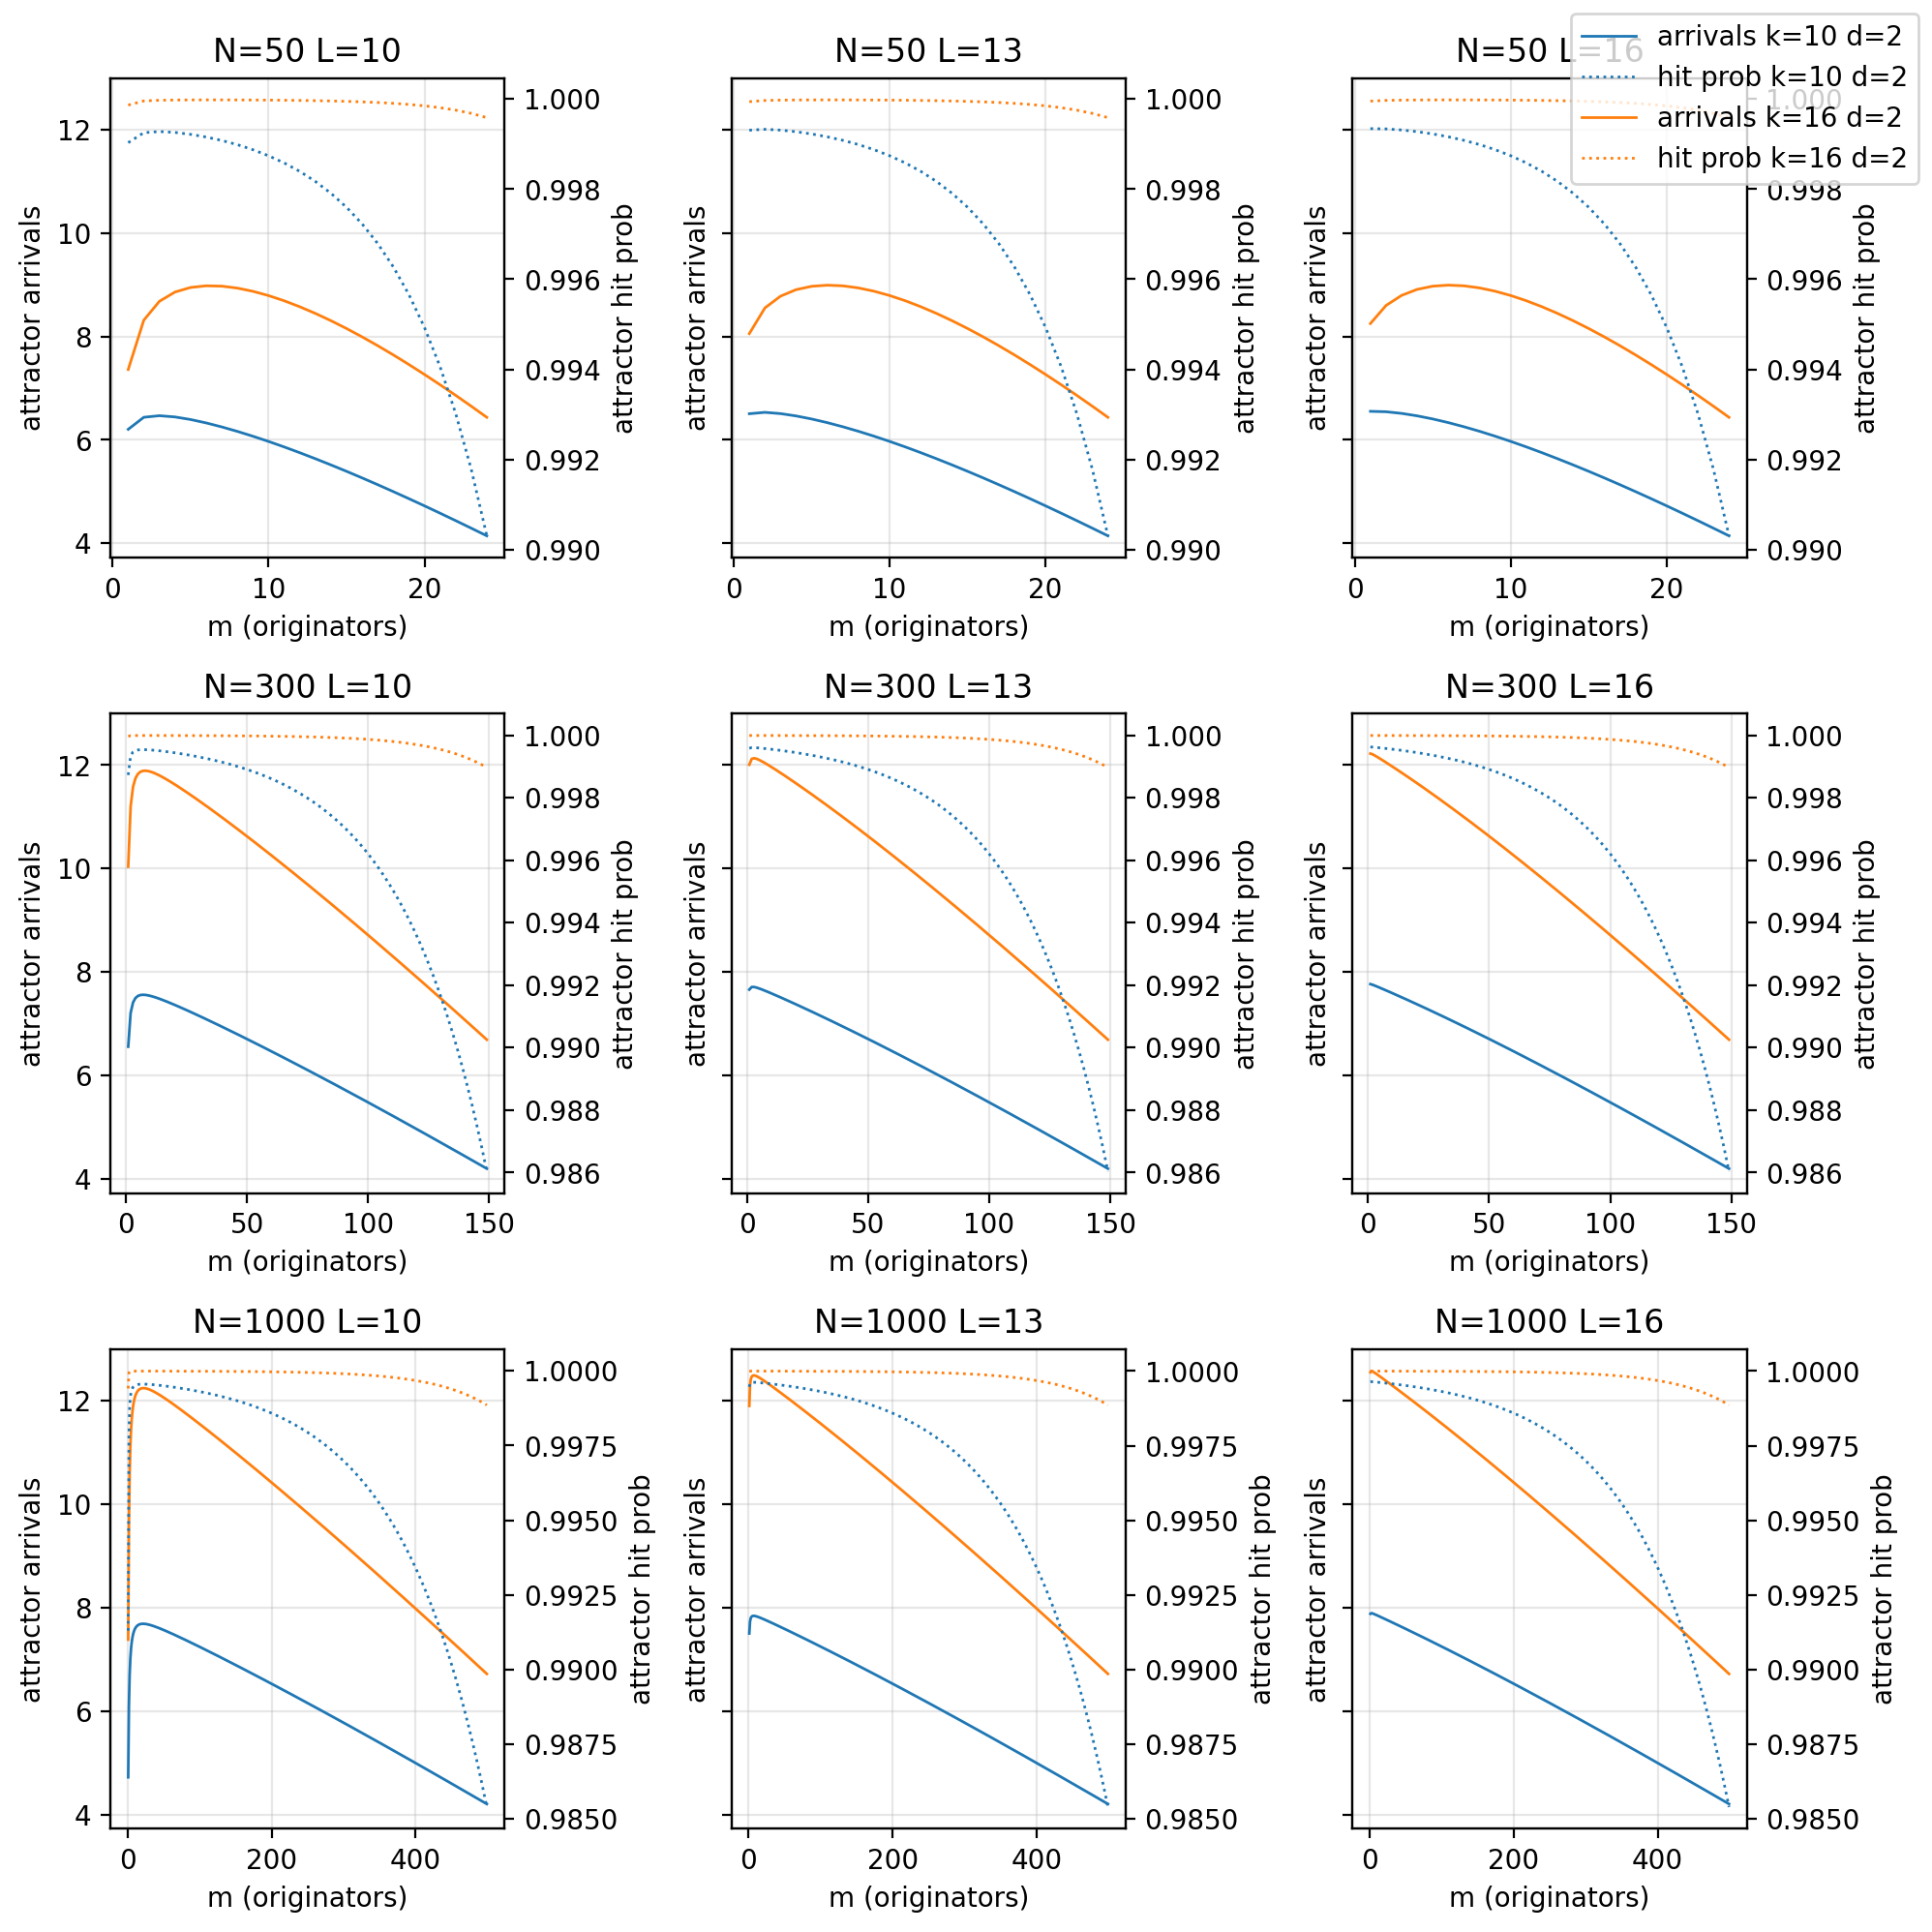

In [8]:
def plot_attractor_in_multi_origin(Ns, ks, Ls, d=2):
    fig, axes = plt.subplots(len(Ns), len(Ls), figsize=(10, 10), sharex=False, sharey=True)
    legend_handles = []
    legend_labels = []
    for i, N in enumerate(Ns):
        for j, L in enumerate(Ls):
            ax = axes[i, j]
            ax2 = ax.twinx()
            ax.set_title(f"N={N} L={L}")
            ax.set_xlabel("m (originators)")
            ax.set_ylabel("attractor arrivals")
            ax2.set_ylabel("attractor hit prob")
            ax.grid(True, alpha=0.3)
            for k in ks:
                ms = list(range(1, N//2))
                results = [attractor_gossip(N=N, k=k, d=d, m=m, L=L) for m in ms]
                options = f"k={k} d={d}"
                line1, = ax.plot(
                    ms,
                    [r["attractor_arrivals"] for r in results],
                    linewidth=1,
                    label=f"arrivals {options}" if (i == 0 and j == 0) else "_nolegend_",
                )
                line2, = ax2.plot(
                    ms,
                    [r["attractor_hit_prob"] for r in results],
                    linewidth=1,
                    linestyle=":",
                    label=f"hit prob {options}" if (i == 0 and j == 0) else "_nolegend_",
                )
                if i == 0 and j == 0:
                    legend_handles.extend([line1, line2])
                    legend_labels.extend([line1.get_label(), line2.get_label()])
    fig.legend(legend_handles, legend_labels, loc="upper right")
    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

plot_attractor_in_multi_origin(Ns=[50, 300, 1000], ks=[10, 16], Ls=[10, 13, 16])